# M5 Forecasting - Model Training and Evaluation

This notebook demonstrates:
- Feature engineering
- Model training with XGBoost and LightGBM
- Baseline comparison (naive lag-1, seasonal lag-7, rolling mean 7d) vs ML models
- Model evaluation and comparison
- After training: metrics, learning curves, feature importance per model, daily actual vs predictions + baselines, then sample series and residual plot for each model (e.g. XGBoost and LightGBM)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append('..')

from src.pipeline.train_pipeline import TrainingPipeline
from src.utils.config import load_config
from src.evaluation.plots import display_training_report_plots

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Initialize training pipeline
pipeline = TrainingPipeline(config_path='../configs/config.m5_optimized.yaml')

In [3]:
# Run training pipeline (charts are shown in the next cell)
models, results, plot_ctx = pipeline.run(return_plot_inputs=True)

2026-04-17 15:00:58,428 - src.pipeline.train_pipeline - INFO - ============================================================
2026-04-17 15:00:58,429 - src.pipeline.train_pipeline - INFO - Starting Training Pipeline
2026-04-17 15:00:58,429 - src.pipeline.train_pipeline - INFO - ============================================================
2026-04-17 15:00:58,429 - src.pipeline.train_pipeline - INFO - Loading data...
2026-04-17 15:00:58,430 - src.data.loader - INFO - Loading calendar from /Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/data/raw/calendar.csv
2026-04-17 15:00:58,437 - src.data.loader - INFO - Loading sales from /Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/data/raw/sales_train_validation.csv
2026-04-17 15:00:59,812 - src.data.loader - INFO - Loading prices from /Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/data/raw/sell_prices.csv
2026-04-17 15:01:00,852 - src.data.loader - INFO - Creating base dataset
202

/Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/notebooks/../src/features/engineering.py:171: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['price_change'] = df.groupby(group_cols)['sell_price'].pct_change()


2026-04-17 15:01:05,422 - src.features.engineering - INFO - Creating event features
2026-04-17 15:01:05,761 - src.features.engineering - INFO - Creating lag features: [1, 7, 14, 28]
2026-04-17 15:01:06,032 - src.features.engineering - INFO - Creating rolling features: windows=[7, 14, 28], functions=['mean', 'std']


/Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/notebooks/../src/features/engineering.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'{target_col}_lag_{lag}'] = df.groupby(group_cols)[target_col].shift(lag)
/Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/notebooks/../src/features/engineering.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'{target_col}_lag_{lag}'] = df.groupby(group_cols)[target_col].shift(lag)
/Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/notebooks/../src/features/engineering.py:44: FutureWarning: The defa

2026-04-17 15:01:06,499 - src.features.engineering - INFO - Feature engineering complete. Total features: 63
2026-04-17 15:01:06,855 - src.pipeline.train_pipeline - INFO - Prepared 45 features
2026-04-17 15:01:06,886 - src.pipeline.train_pipeline - INFO - Splitting data...
2026-04-17 15:01:07,924 - src.pipeline.train_pipeline - INFO - Train: 1857000 rows (2011-01-29 00:00:00 to 2016-02-28 00:00:00)
2026-04-17 15:01:07,924 - src.pipeline.train_pipeline - INFO - Validation: 28000 rows (2016-02-29 00:00:00 to 2016-03-27 00:00:00)
2026-04-17 15:01:07,925 - src.pipeline.train_pipeline - INFO - Test: 28000 rows (2016-03-28 00:00:00 to 2016-04-24 00:00:00)
2026-04-17 15:01:07,973 - src.pipeline.train_pipeline - INFO - Training models...
2026-04-17 15:01:08,264 - src.models.trainer - INFO - Training XGBoost model
2026-04-17 15:01:14,892 - src.models.trainer - INFO - XGBoost training completed. Best iteration: 249
2026-04-17 15:01:14,892 - src.models.trainer - INFO - Training LightGBM model
[Li

### Train / eval — figures

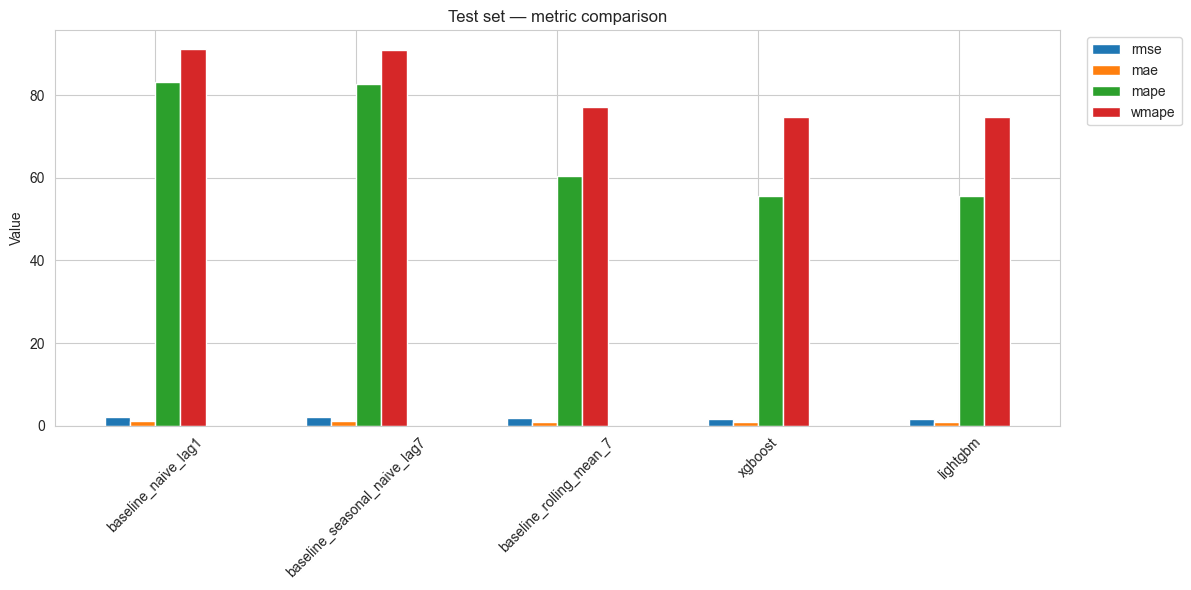

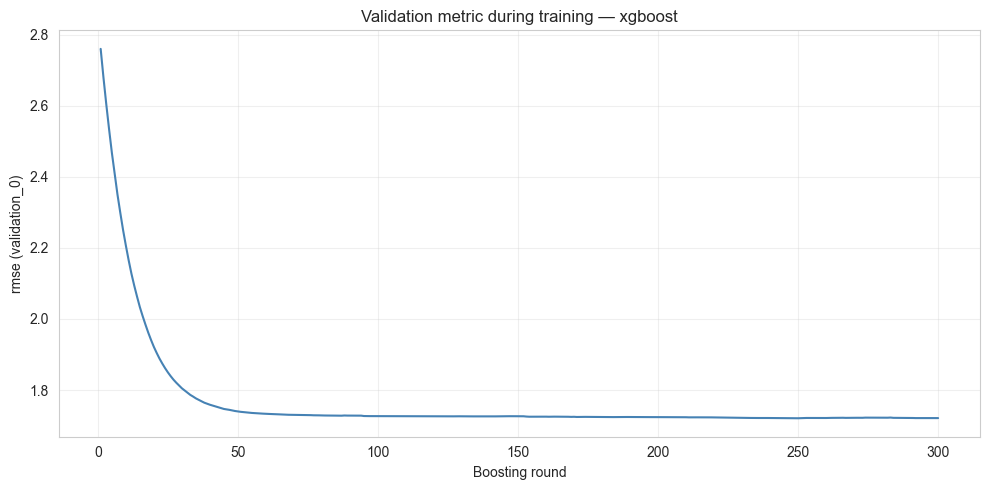

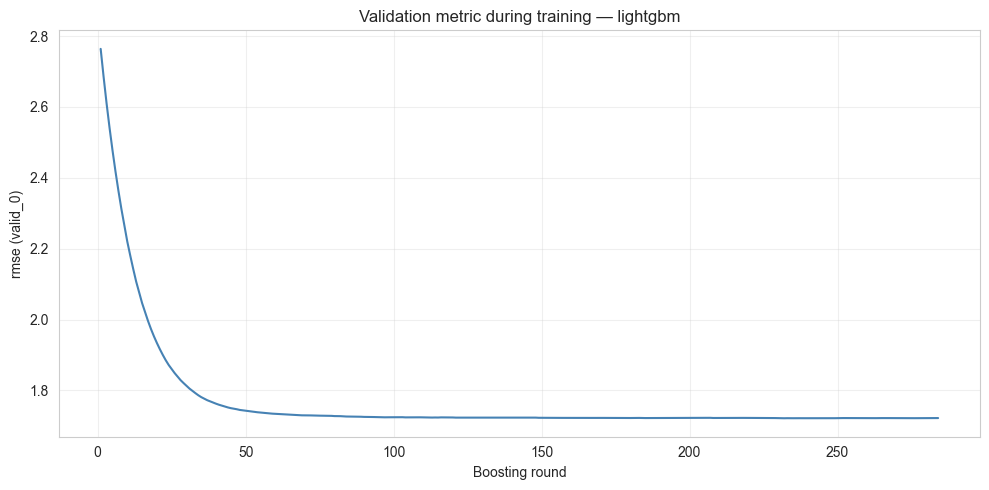

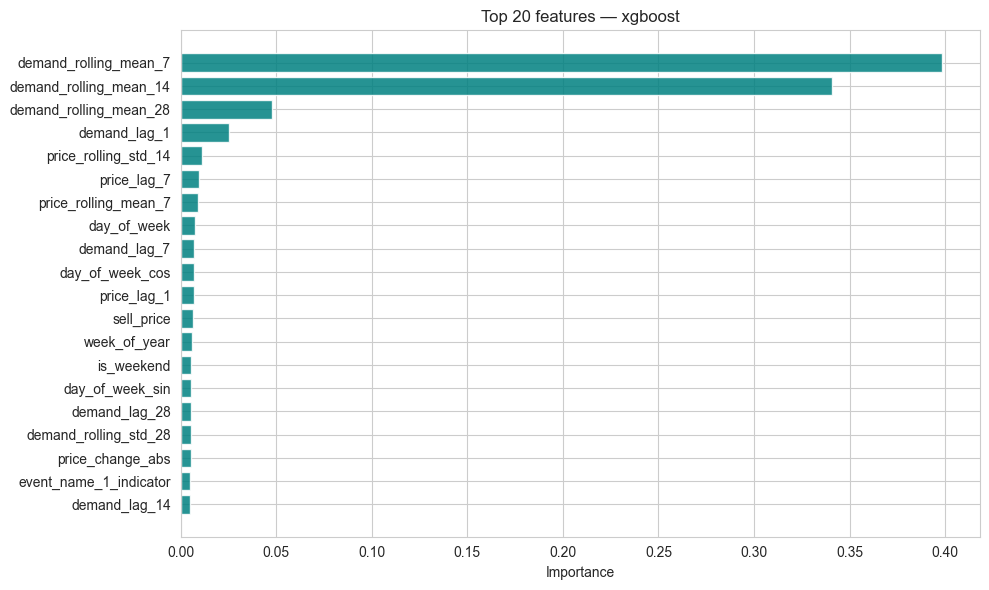

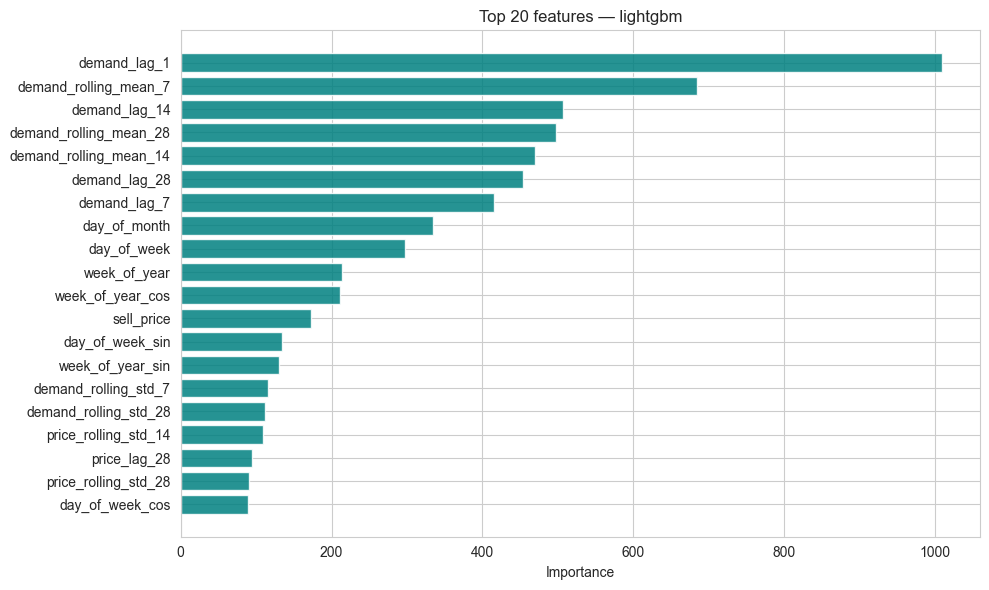

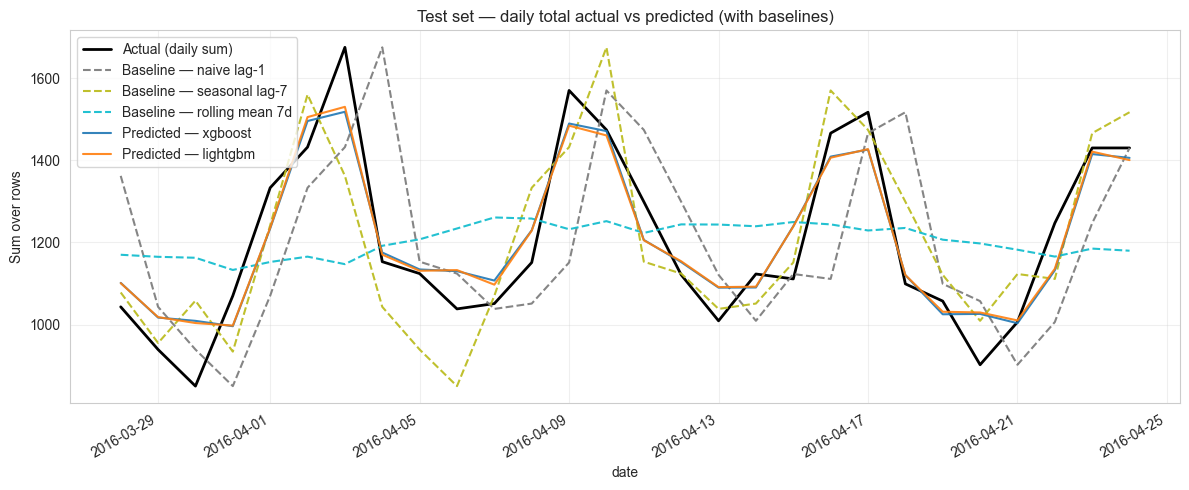

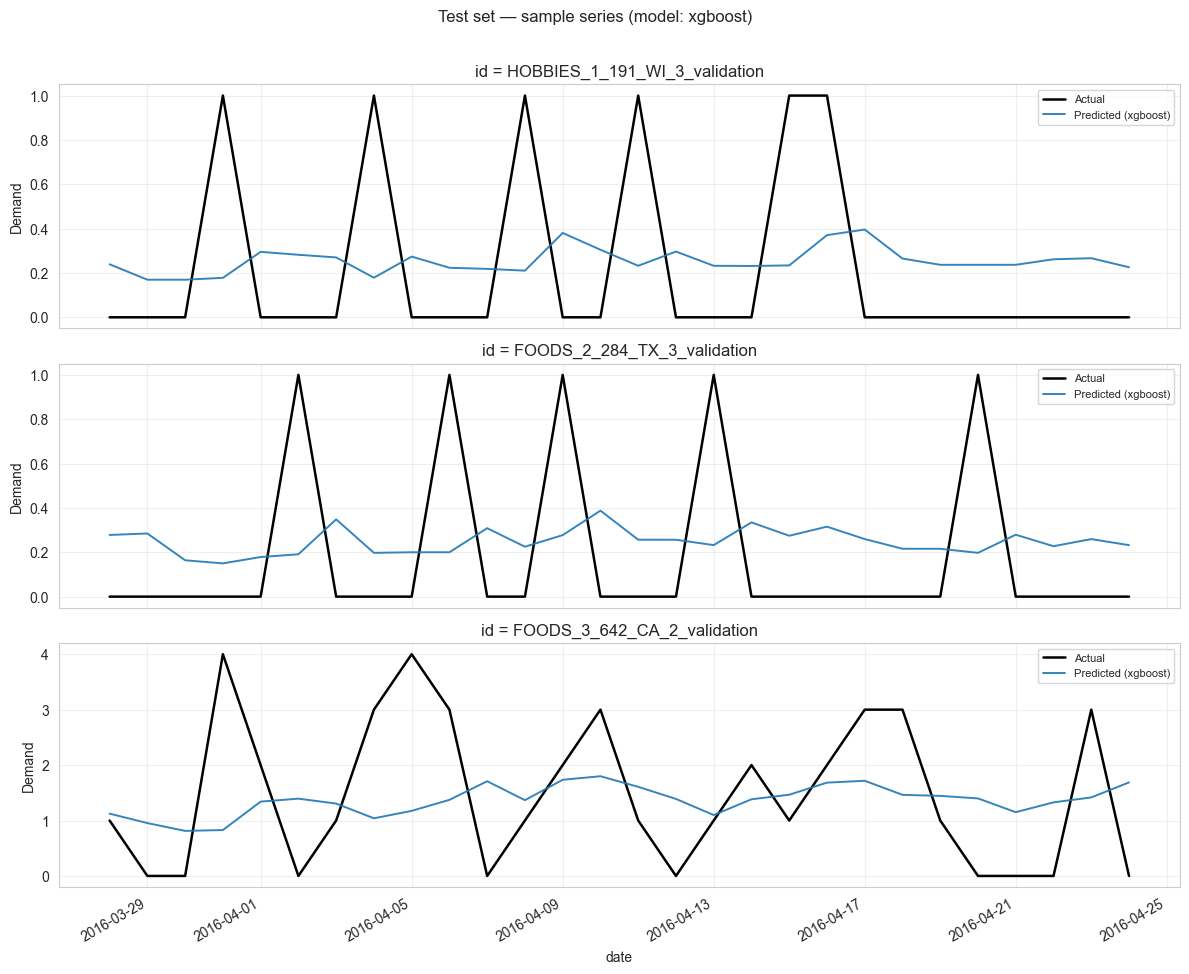

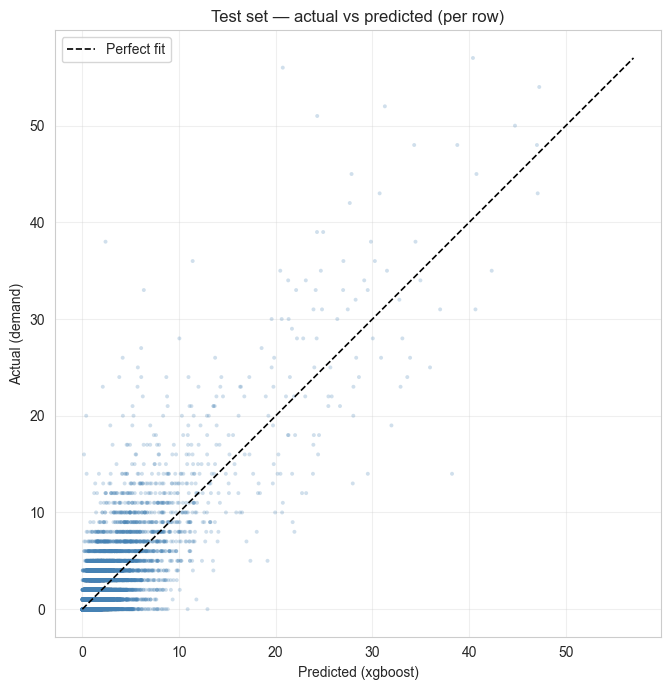

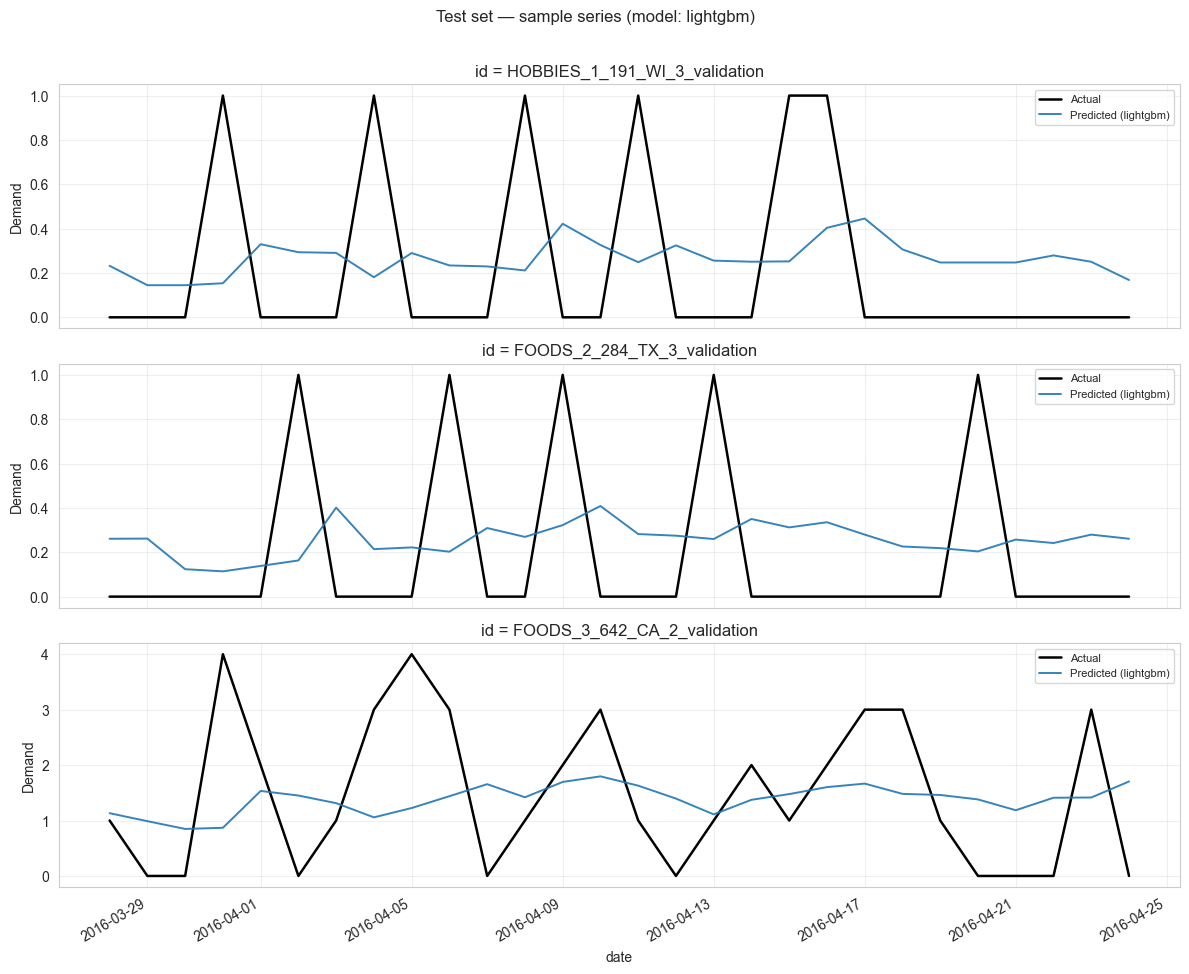

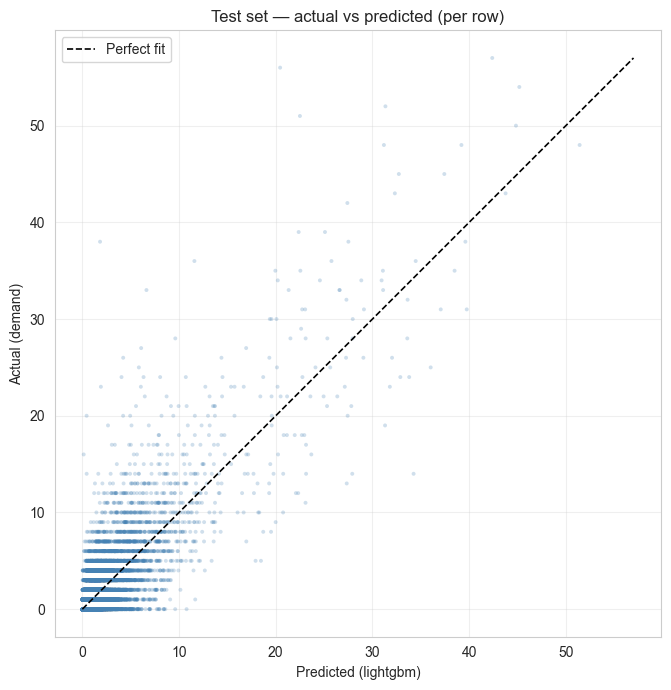

In [4]:
# Figures: metrics → learning curves + FI per model → daily (ML + baselines) →
# sample series + residual scatter for each trained model (xgboost & lightgbm by default).
from IPython.display import Markdown, display

display(Markdown("### Train / eval — figures"))
training_cfg = pipeline.config.get("training", {}) or {}
display_training_report_plots(
    test_results=results,
    test_df=plot_ctx["test_df"],
    feature_cols=plot_ctx["feature_cols"],
    model_trainer=pipeline.model_trainer,
    date_col=training_cfg.get("date_col", "date"),
    target_col=training_cfg.get("target_col", "demand"),
    # forecast_models="lightgbm"  # hoặc ("xgboost", "lightgbm"); bỏ dòng để vẽ mọi model
)


In [5]:
# Compare model performance (numeric table; bar chart is in the figures cell above)
comparison_df = pd.DataFrame(results).T
print("Model Comparison:")
print(comparison_df)

Model Comparison:
                                  rmse       mae       mape      wmape
baseline_naive_lag1           2.216561  1.097500  83.092294  91.132859
baseline_seasonal_naive_lag7  2.210365  1.095429  82.665449  90.960854
baseline_rolling_mean_7       1.751600  0.928602  60.539927  77.108117
xgboost                       1.623076  0.900498  55.513550  74.774446
lightgbm                      1.621449  0.900369  55.676499  74.763772


In [6]:
# Feature importance (bar charts are in the figures cell above)
for model_name in models.keys():
    importance_df = pipeline.model_trainer.get_feature_importance(model_name, top_n=20)
    print(f"\nTop 20 Features - {model_name.upper()}:")
    print(importance_df)


Top 20 Features - XGBOOST:
                   feature  importance
39   demand_rolling_mean_7    0.398270
41  demand_rolling_mean_14    0.340631
43  demand_rolling_mean_28    0.047868
35            demand_lag_1    0.025561
28    price_rolling_std_14    0.011320
20             price_lag_7    0.009617
25    price_rolling_mean_7    0.009148
4              day_of_week    0.007478
36            demand_lag_7    0.007232
14         day_of_week_cos    0.007001
19             price_lag_1    0.006937
3               sell_price    0.006412
6             week_of_year    0.005957
8               is_weekend    0.005701
13         day_of_week_sin    0.005696
38           demand_lag_28    0.005378
44   demand_rolling_std_28    0.005332
24        price_change_abs    0.005186
31  event_name_1_indicator    0.005168
37           demand_lag_14    0.005015

Top 20 Features - LIGHTGBM:
                   feature  importance
35            demand_lag_1        1009
39   demand_rolling_mean_7         685
37     